# BEoRN: Post-processing with Merger Trees

This notebook demonstrates how to use **BEoRN** with **per-halo accretion rates** derived from merger trees. Instead of assuming the same exponential growth rate α for all halos, we fit α individually for each halo from its mass accretion history along the main progenitor branch.

**Data used:** [THESAN-DARK 2](https://thesan-project.com) — a publicly available dark-matter-only simulation (95.5 cMpc/h box, 1050³ particles, LHaloTree merger trees).

**Prerequisites:** Have the THESAN-DARK snapshot and merger tree data available (see `FILE_ROOT` in the paths cell below). The simplified tree cache is built automatically in Section 3 the first time you run the notebook.

---

### How this tutorial is structured

We follow the same pattern as the `nbody_simulation_halos` notebook: we write a **custom `MyMergerTreeLoader`** class that you can adapt for any simulation with merger trees. BEoRN ships a ready-made `ThesanLoader` that does exactly what `MyMergerTreeLoader` does below, but showing the explicit implementation makes it easy to adapt the code to other datasets (IllustrisTNG, EAGLE, Bolshoi, etc.).

The key difference from the N-body tutorial is that the loader now also reads the merger tree and returns a `HaloCatalog` with a per-halo `alphas` array.

In [1]:
import os
import numpy as np
from tqdm import tqdm
from pathlib import Path
import h5py
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

import logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

import beorn
from beorn.particle_mapping import map_particles_to_mesh

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 12, 'axes.titlesize': 14,
})


INFO:numexpr.utils:NumExpr defaulting to 10 threads.


In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
# FILE_ROOT: root of the THESAN-DARK data tree.  Expected layout:
#   FILE_ROOT/output/groups_*/          ← FoF group catalogs
#   FILE_ROOT/output/snapdir_*/         ← DM particle snapshots
#   FILE_ROOT/postprocessing/offsets/   ← subhalo offset files
#   FILE_ROOT/postprocessing/trees/LHaloTree/  ← raw LHaloTree HDF5 files
FILE_ROOT  = Path(os.environ.get("PROJECT", "input")) / "Thesan-Dark-2"

# CACHE_ROOT: intermediate results (radiation profiles, tree cache)
CACHE_ROOT = Path("cache")
CACHE_ROOT.mkdir(parents=True, exist_ok=True)
CACHE_FILE = CACHE_ROOT / "Thesan-Dark-2_tree_cache.hdf5"

# OUTPUT_ROOT: where painted signal cubes are written
OUTPUT_ROOT = Path(os.environ.get("SCRATCH", "output"))

# ── Snapshot to inspect ────────────────────────────────────────────────────
# Snap 49 ≈ z=7.4 in THESAN-DARK 2; adjust if your download differs.
SNAP_IDX = 49

# ── Resolution flag ────────────────────────────────────────────────────────
IS_HIGH_RES    = False  # True for THESAN-DARK 1 (2100³ particles)
PARTICLE_COUNT = 2100**3 if IS_HIGH_RES else 1050**3


In [3]:
import beorn

import matplotlib as mpl
mpl.rcParams.update({
    'font.size': 14, 'axes.labelsize': 14,
    'xtick.labelsize': 12, 'ytick.labelsize': 12,
    'legend.fontsize': 12, 'axes.titlesize': 14,
})

## 1. Set simulation and astrophysical parameters

### THESAN-DARK 2 specifics
- Box: **95.5 cMpc/h**
- Mass resolution: **2.96 × 10⁷ M☉** per particle → minimum resolved halo ~10⁹ M☉
- Cosmology: Planck 2015 (same as IllustrisTNG)

### Merger tree settings
- `mass_accretion_lookback = 10`: use 10 snapshots of lookback history when fitting α (Moll 2025, Fig. 3 — mean stabilises at n=10)
- `alpha_fallback = "mean"`: halos not in the tree get the mean α of their snapshot (adapts with redshift)
- `halo_mass_accretion_alpha`: set to [0, 5] with 26 bins — covers the full observed range in THESAN (Moll 2025, Sec. 4.3)

In [4]:
parameters = beorn.structs.Parameters()

## Simulation grid — must match the THESAN data
parameters.simulation.Lbox  = 95.5    # comoving Mpc/h
parameters.simulation.Ncell = 128     # grid resolution for painting
parameters.simulation.cores = 1

## Merger tree settings
parameters.source.mass_accretion_lookback = 10   # lookback snapshots for alpha fit
parameters.source.alpha_fallback          = 'mean'  # fallback for halos not in tree

## Solver: redshift grid and alpha bins
# Covering z = 6–10 is sufficient for a single-snapshot tutorial at z≈7.4.
# Widen this range if you want to paint multiple snapshots.
parameters.solver.redshifts                 = np.arange(10.0, 5.5, -0.5)
parameters.solver.halo_mass_accretion_alpha = np.linspace(0, 5, 26)  # 25 bins, 0–5
parameters.solver.halo_mass_bin_min         = 1e9   # ~resolution limit of THESAN-DARK 2
parameters.solver.halo_mass_bin_max         = 1e13
parameters.solver.halo_mass_nbin            = 40

## Cosmology (Planck 2015, matching THESAN)
parameters.cosmology.Om  = 0.3089
parameters.cosmology.Ob  = 0.0486
parameters.cosmology.Ol  = 1 - 0.3089
parameters.cosmology.h0  = 0.6774

## Source model — 'boosted' model from Moll (2025) / Schaeffer et al. (2023)
parameters.source.f_st   = 0.1
parameters.source.Mp     = 2.8e10 * parameters.cosmology.h0   # pivot mass
parameters.source.g1     = 0.49
parameters.source.g2     = -0.61
parameters.source.g3     = 4
parameters.source.g4     = -4
parameters.source.halo_mass_min = 1e9

# X-ray
parameters.source.energy_cutoff_min_xray = 500
parameters.source.energy_cutoff_max_xray = 10000
parameters.source.energy_min_sed_xray    = 200
parameters.source.energy_max_sed_xray    = 10000
parameters.source.alS_xray               = 1.5
parameters.source.xray_normalisation     = 0.3 * 3.4e40

# Lyman-alpha
parameters.source.n_lyman_alpha_photons = 9690

# Ionisation
parameters.source.Nion    = 2000
parameters.source.f0_esc  = 0.2
parameters.source.pl_esc  = 0.5


### Source model visualization

Before running anything, it is useful to inspect the astrophysical source model implied by the parameters above. The two key efficiency functions are:

- **Star-formation efficiency** $f_*(M_h)$: fraction of accreted baryons converted into stars (double power-law with a low-mass suppression below $M_t$).
- **Escape fraction** $f_\mathrm{esc}(M_h)$: fraction of ionising photons that escape into the IGM (power-law in halo mass).

These two functions, multiplied together and by $N_\mathrm{ion}$, set the ionising emissivity of each halo.

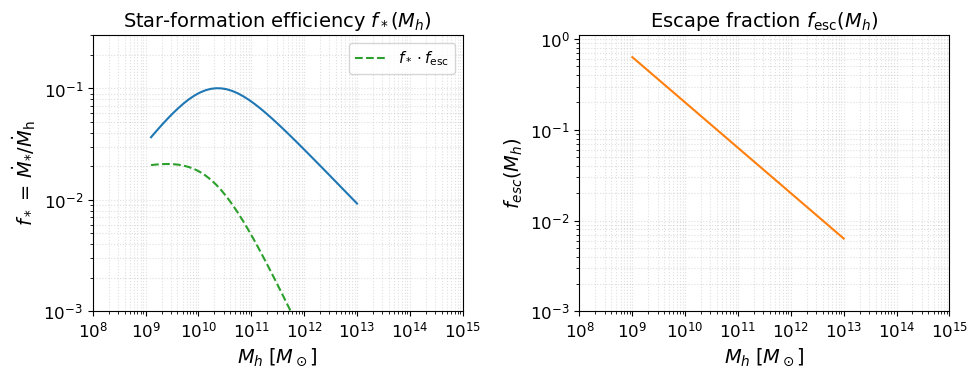

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

beorn.plotting.draw_star_formation_rate(axes[0], parameters, color='C0')
beorn.plotting.draw_f_esc(axes[1], parameters, color='C1')

# Overlay f_star * f_esc on the left panel
Mh_grid = parameters.solver.halo_mass_bins
keep = (Mh_grid > parameters.source.halo_mass_min) & (Mh_grid <= parameters.source.halo_mass_max)
Mh_plot = Mh_grid[keep]
from beorn.astro import f_star_Halo, f_esc as f_esc_func
combined = f_star_Halo(parameters, Mh_plot) * f_esc_func(parameters, Mh_plot)
axes[0].loglog(Mh_plot, combined, color='C2', ls='--', label=r'$f_* \cdot f_\mathrm{esc}$')
axes[0].legend(fontsize=11)

axes[0].set_title(r'Star-formation efficiency $f_*(M_h)$')
axes[1].set_title(r'Escape fraction $f_\mathrm{esc}(M_h)$')

for ax in axes:
    ax.set_xlabel(r'$M_h \; [M_\odot]$')
    ax.grid(True, which='both', ls=':', alpha=0.4)
    ax.set_xlim(1e8, 1e15)
axes[0].set_ylim(1e-3, 3e-1)
axes[1].set_ylim(1e-3, 1.1)

plt.tight_layout()
plt.show()

## 2. Precompute radiation profiles

Profiles are computed over a 2D grid of **(halo mass, α)** bins and cached.  Because the α dimension is now large (25 bins vs. the default 9), the profile grid is larger — this is the expected cost of individual accretion rate treatment.

In [6]:
cache_handler = beorn.io.Handler(CACHE_ROOT)

solver = beorn.precomputation.RadiationProfileSolver(parameters, parameters.solver.redshifts)
profiles = solver.get_or_compute_profiles(cache_handler)

print(f"Profile shape (rho_heat): {profiles.rho_heat.shape}")
print(f"  (n_r, n_mass_bins, n_alpha_bins, n_z)")

INFO:beorn.io.handler:Using persistence directory at cache
INFO:beorn.precomputation.solver:Radiation profiles not found in cache. Launching a single computation process.
INFO:beorn.precomputation.solver:============================================================
BEoRN model summary
  Cosmology   : Om=0.3089, Ob=0.0486, h0=0.6774, sigma_8=0.83
  Grid        : Ncell=128, Lbox=95.5 Mpc/h
  Profile z   : z=10.0 -> 6.0 (9 steps)
  1D RT bins  : 1.0e+09 - 1.0e+13 Msun at z=6.0 (40 bins, traced back via exp. accretion)
  Source      : f_st=0.1, Nion=2000, f0_esc=0.2
  X-ray       : norm=1.02e+40, E=[500, 10000] eV
  Lyman-alpha : n_phot=9690, star-forming above 1.0e+09 Msun
  Beorn hash  : 183843ad
INFO:beorn.precomputation.solver:param.solver.fXh is set to constant. We will assume f_X,h = 2e-4**0.225
INFO:beorn.precomputation.solver:Computing profiles for 9 redshifts, 39 halo mass bins and 25 alpha bins.
INFO:beorn.structs.base_struct:Data written to cache/radiation_profiles_legacy/Radiati

Profile shape (rho_heat): (200, 39, 25, 9)
  (n_r, n_mass_bins, n_alpha_bins, n_z)


### Inspecting the pre-computed 1D profiles

The figure below mirrors Figure 2 of [Schaeffer et al. 2023](https://arxiv.org/abs/2305.15466). Each panel corresponds to a selected halo mass bin and shows how the radial profile evolves with redshift (blue → red):

1. **Halo mass accretion history** — exponential MAR model (grey) vs. Behroozi et al. 2020 simulations (gold).
2. **Lyman-α flux profile** $\rho_\alpha(r)$ — sets the WF coupling $x_\alpha$.
3. **Kinetic temperature profile** $T_k(r)$ — driven by X-ray heating.
4. **Ionization fraction** $x_\mathrm{HII}(r)$ — sharp bubble front expanding with time.

Because we now have 25 α bins, we show three representative values — slow (α=0.3), fiducial (α=0.79), and fast (α=2.0) accretion — to illustrate how the profile shape changes with the halo accretion rate. Adjust `mass_index` and the lists to explore further.

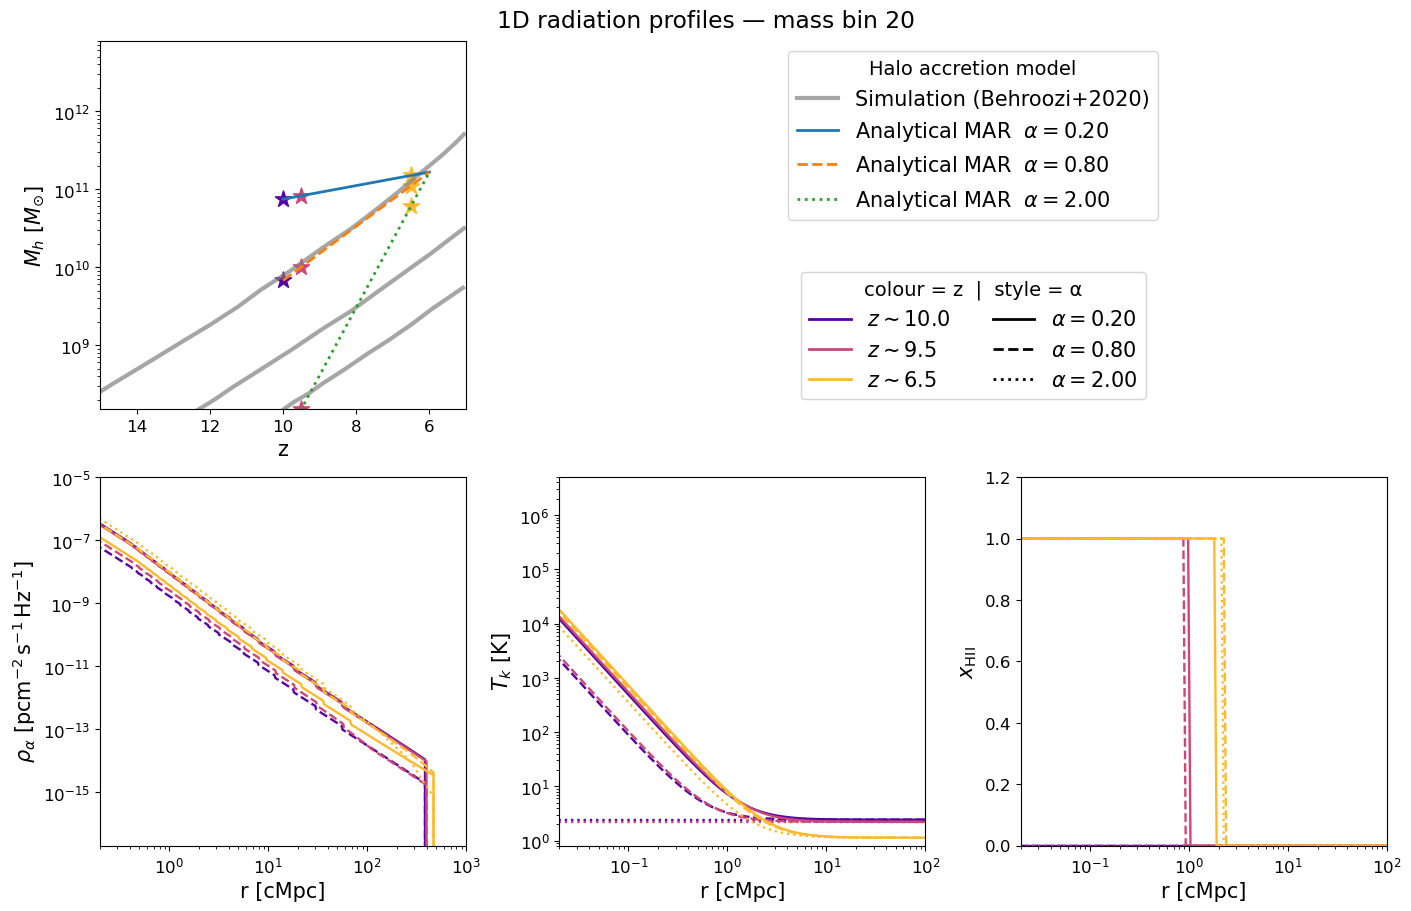

In [7]:
mass_index = parameters.solver.halo_mass_nbin // 2
profile_redshifts = [13.0, 9.5, 6.5]
# Show three α values to highlight the impact of different accretion rates
profile_alphas = [0.3, 0.79, 2.0]

beorn.plotting.plot_1D_profiles(
    parameters,
    profiles,
    mass_index=mass_index,
    redshifts=profile_redshifts,
    alphas=profile_alphas,
    label=f"1D radiation profiles — mass bin {mass_index}",
    fontsize=15,
)

## 3. Prepare the simplified tree cache

BEoRN's merger tree loader reads a **flat HDF5 cache** containing four parallel arrays extracted from the raw LHaloTree files.  The cache is built once and reused on subsequent runs.

The cache schema is simulation-agnostic — only these four arrays are required:

| Dataset | dtype | Description |
|---|---|---|
| `tree_halo_ids` | int64 | subhalo index within its snapshot |
| `tree_snap_num` | int32 | snapshot index |
| `tree_mass` | float32 | halo mass (10¹⁰ M☉/h — raw THESAN units) |
| `tree_main_progenitor` | int64 | flat-array index of main progenitor, or -1 |

> **Other simulations:** Replace the reading code below with whatever reads your native format (Consistent-Trees, SubLink, etc.) while keeping the output schema identical.

In [8]:
if CACHE_FILE.exists():
    logger.info(f"Tree cache already exists: {CACHE_FILE} — skipping extraction.")
else:
    logger.info("Building tree cache (runs once, result cached to disk)…")

    tree_dir   = FILE_ROOT / "postprocessing" / "trees" / "LHaloTree"
    tree_files = sorted(tree_dir.glob("trees_sf1_*.hdf5"))
    tree_files = [f for f in tree_files if f.name != CACHE_FILE.name]
    if not tree_files:
        raise FileNotFoundError(f"No LHaloTree files found in {tree_dir}")

    # Read metadata from the first file's header
    with h5py.File(tree_files[0], "r") as f:
        snapshot_redshifts = f["Header"]["Redshifts"][:].tolist()
        particle_mass_1e10 = float(f["Header"].attrs["ParticleMass"])  # 10^10 M☉/h
        _h_header = float(
            f["Header"].attrs["HubbleParam"]
            if "HubbleParam" in f["Header"].attrs
            else parameters.cosmology.h0
        )
    logger.info(f"  {len(tree_files)} tree file(s), {len(snapshot_redshifts)} snapshots")

    # Auto-detect mass field (LenType preferred for THESAN-DARK because it uses
    # integer particle counts which give monotonic histories; SubhaloMassType is
    # a bound-mass estimate that can decrease due to tidal stripping).
    with h5py.File(tree_files[0], "r") as _f:
        _t      = _f["Tree0"]
        _fields = set(_t.keys())

        _mass_field = "LenType" if "LenType" in _fields else "SubhaloMassType"
        logger.info(f"Mass field: {_mass_field}")

        # Identify FoF-first-halo pointer (capitalization varies between releases)
        _fof_field = next(
            (name for name in ("FirstHaloInFOFgroup", "FirstHaloInFOFGroup",
                               "FirstHaloInFoFGroup", "FOFHalo")
             if name in _fields),
            None,
        )
        if _fof_field is None:
            raise KeyError(
                f"Cannot find a FoF-first-halo pointer in {list(_fields)}. "
                "Check the field names printed by the inspect-tree cell."
            )
        logger.info(f"FoF-central field: {_fof_field}")

    all_halo_ids, all_snap_nums, all_masses, all_main_prog, all_is_central = [], [], [], [], []
    global_offset = 0

    for tree_file in tree_files:
        with h5py.File(tree_file, "r") as f:
            tree_keys   = sorted(k for k in f.keys() if k.startswith("Tree"))
            file_offset = 0

            for tk in tree_keys:
                tree    = f[tk]
                n_local = tree["SnapNum"].shape[0]

                snap_num      = tree["SnapNum"][:].astype(np.int32)
                subhalo_index = tree["SubhaloNumber"][:].astype(np.int64)
                first_prog    = tree["FirstProgenitor"][:].astype(np.int64)

                if _mass_field == "LenType":
                    mass = tree["LenType"][:, 1].astype(np.float32) * particle_mass_1e10
                else:
                    mass = tree["SubhaloMassType"][:, 1].astype(np.float32)

                # A halo is central iff it is its own FoF-first pointer
                fof_first  = tree[_fof_field][:].astype(np.int64)
                local_idx  = np.arange(n_local, dtype=np.int64)
                is_central = (fof_first == local_idx)

                abs_offset = global_offset + file_offset
                main_prog  = np.where(
                    first_prog >= 0,
                    first_prog + abs_offset,
                    np.int64(-1),
                )

                all_halo_ids.append(subhalo_index)
                all_snap_nums.append(snap_num)
                all_masses.append(mass)
                all_main_prog.append(main_prog)
                all_is_central.append(is_central)
                file_offset += n_local

        logger.info(f"  {tree_file.name}: {file_offset:,} entries "
                    f"(cumulative {global_offset + file_offset:,})")
        global_offset += file_offset

    tree_halo_ids        = np.concatenate(all_halo_ids).astype(np.int64)
    tree_snap_nums_arr   = np.concatenate(all_snap_nums).astype(np.int32)
    tree_masses          = np.concatenate(all_masses).astype(np.float32)
    tree_main_progenitor = np.concatenate(all_main_prog).astype(np.int64)
    tree_is_central      = np.concatenate(all_is_central)

    with h5py.File(CACHE_FILE, "w") as f:
        f.attrs["format_version"]                = 2
        f.attrs["generated_by"]                  = "beorn"
        f.attrs["simulation_code"]               = "THESAN-DARK-1" if IS_HIGH_RES else "THESAN-DARK-2"
        f.attrs["is_high_res"]                   = IS_HIGH_RES
        f.attrs["hubble_param"]                  = _h_header
        f.attrs["mass_field_used"]               = _mass_field
        f.attrs["fof_field_used"]                = _fof_field
        f.attrs["n_snapshots"]                   = len(snapshot_redshifts)
        f.attrs["n_tree_files"]                  = len(tree_files)
        f.attrs["n_total_entries"]               = int(tree_halo_ids.size)
        f.attrs["particle_mass_1e10_Msol_per_h"] = particle_mass_1e10

        f.create_dataset("snapshot_redshifts",   data=np.array(snapshot_redshifts), compression="gzip")
        f.create_dataset("tree_halo_ids",        data=tree_halo_ids,        compression="gzip")
        f.create_dataset("tree_snap_num",        data=tree_snap_nums_arr,   compression="gzip")
        f.create_dataset("tree_mass",            data=tree_masses,          compression="gzip")
        f.create_dataset("tree_main_progenitor", data=tree_main_progenitor, compression="gzip")
        f.create_dataset("tree_is_central",      data=tree_is_central,      compression="gzip")

    logger.info(f"Tree cache saved → {CACHE_FILE}  ({tree_halo_ids.size:,} total entries, "
                f"{tree_is_central.sum():,} centrals)")


INFO:__main__:Building tree cache (runs once, result cached to disk)…


KeyError: "Unable to synchronously open attribute (can't locate attribute: 'HubbleParam')"

## 4. Write a merger tree loader for your simulation

BEoRN provides `MergerTreeLoader` as an abstract base class for simulations with merger trees.  To use your own data you subclass it and implement four methods:

| Method | What it does |
|---|---|
| `redshifts` (property) | Returns a sorted array of available snapshot redshifts |
| `load_tree_cache()` | Reads the flat HDF5 cache and returns the four arrays |
| `get_halo_information_from_catalog()` | Reads positions, masses, and subhalo→group mapping for one snapshot |
| `load_density_field()` | Reads the density field for one snapshot |

The base class handles the rest: walking main progenitor branches, calling `vectorized_alpha_fit`, applying fallback values and alpha range clamping, and assembling the `HaloCatalog`.

> **Ready-made class:** BEoRN ships `ThesanLoader` which does exactly what `MyMergerTreeLoader` does below.  The custom version is shown here so you can adapt it for other simulations.

In [ ]:
class MyMergerTreeLoader(beorn.load_input_data.MergerTreeLoader):
    """Example merger tree loader for THESAN-DARK.

    Inherits tree walking, alpha fitting, fallback handling, and
    HaloCatalog assembly from MergerTreeLoader.  Only simulation-specific
    I/O is implemented here.

    Replace the four methods below with code that reads your simulation
    format.  The output schema must stay the same.
    """

    simulation_code = "THESAN-DARK"

    def __init__(self, parameters, *, cache_file=CACHE_FILE, is_high_res=IS_HIGH_RES):
        super().__init__(parameters)

        self.thesan_root    = FILE_ROOT
        self.offset_root    = self.thesan_root / "postprocessing" / "offsets"
        self.cached_tree    = Path(cache_file)
        self.particle_count = 2100**3 if is_high_res else 1050**3

        # Read snapshot redshifts and h from the HDF5 cache (format_version >= 2)
        with h5py.File(self.cached_tree, "r") as fh:
            redshifts = fh["snapshot_redshifts"][:]
            self.h    = float(fh.attrs.get("hubble_param",
                                           parameters.cosmology.h0))

        # Collect and sort snapshot directories by index
        catalogs  = sorted((self.thesan_root / "output").glob("groups_*"))
        off_files = sorted(self.offset_root.glob("offsets_*"))

        # Restrict to the solver redshift range
        z_min = parameters.solver.redshifts.min()
        z_max = parameters.solver.redshifts.max()
        idx = np.where((redshifts >= z_min) & (redshifts <= z_max))[0]

        self._redshifts    = redshifts[idx]
        self._catalogs     = [catalogs[i]  for i in idx]
        self._offset_files = [off_files[i] for i in idx]

        logger.info(
            f"MyMergerTreeLoader: {self._redshifts.size} snapshots "
            f"z={self._redshifts.max():.2f}\u2192{self._redshifts.min():.2f}"
        )

    # ── 1. Snapshot redshifts ─────────────────────────────────────────────

    @property
    def redshifts(self):
        return self._redshifts

    # ── 2. Load the flat tree cache ───────────────────────────────────────

    def load_tree_cache(self):
        """Read the flat HDF5 cache built in Section 3."""
        with h5py.File(self.cached_tree, "r") as f:
            ids        = f["tree_halo_ids"][:]
            snaps      = f["tree_snap_num"][:]
            mass       = f["tree_mass"][:]
            prog       = f["tree_main_progenitor"][:]
            is_central = f["tree_is_central"][:]
        return ids, snaps, mass, prog, is_central

    # ── 3. Load halo positions, masses, and subhalo→group mapping ─────────

    def get_halo_information_from_catalog(self, redshift_index):
        """Read group positions and masses from THESAN group catalog HDF5 files.

        Returns:
            positions            (N, 3) float — comoving Mpc/h
            masses               (N,)   float — M☉
            subhalo_to_group_map (S,)   int   — subhalo → group index mapping
        """
        catalog_dir = self._catalogs[redshift_index]
        offset_file = self._offset_files[redshift_index]
        snap_files  = sorted(
            catalog_dir.rglob("*.hdf5"),
            key=lambda p: int(p.stem.split(".")[1]),
        )

        with h5py.File(offset_file, "r") as f:
            g_offsets = f["FileOffsets"]["Group"][:]
            s_offsets = f["FileOffsets"]["Subhalo"][:]

        n_g = int(g_offsets[-1] * 1.5)
        n_s = int(s_offsets[-1] * 1.5)

        positions = np.zeros((n_g, 3), dtype=np.float32)
        masses    = np.zeros(n_g, dtype=np.float64)
        smap      = np.zeros(n_s, dtype=np.int64)
        gp, sp    = 0, 0

        for snap_file in snap_files:
            with h5py.File(snap_file, "r") as f:
                if "GroupPos" not in f["Group"]:
                    continue
                gpos  = f["Group"]["GroupPos"][:]
                gmass = f["Group"]["GroupMass"][:]
                ge    = gp + gpos.shape[0]
                positions[gp:ge] = gpos
                masses[gp:ge]    = gmass
                gp = ge

                sub = f["Subhalo"]["SubhaloGrNr"][:]
                se  = sp + sub.shape[0]
                smap[sp:se] = sub
                sp = se

        positions = positions[:gp]
        masses    = masses[:gp]
        smap      = smap[:sp]

        # Unit conversions: kpc/h → Mpc/h,  10^10 M☉/h → M☉
        positions /= (1e3 * self.h)
        masses    *= 1e10 / self.h
        return positions, masses, smap

    # ── 4. Load density field (from raw particle snapshots) ───────────────

    def load_density_field(self, redshift_index):
        """Paint DM particles onto a grid and return overdensity δ = ρ/⟨ρ⟩ - 1.

        Uses map_particles_to_mesh with backend='numpy' (no extra dependencies).
        Other backends: 'numba', 'pylians', 'torch', 'jax'.
        """
        snap_idx   = int(idx[redshift_index])  # absolute snapshot number
        snap_dir   = self.thesan_root / "output" / f"snapdir_{snap_idx:03d}"
        snap_files = sorted(snap_dir.glob("snap_*.hdf5"))

        with h5py.File(snap_files[0], "r") as f:
            box_kpc = float(f["Header"].attrs["BoxSize"])  # kpc/h

        box_mpc = box_kpc * 1e-3 / self.h
        N       = self.parameters.simulation.Ncell
        mesh    = np.zeros((N, N, N), dtype=np.float32)

        for snap in snap_files:
            with h5py.File(snap, "r") as f:
                pos = f["PartType1"]["Coordinates"][:].astype(np.float32)
            pos *= 1e-3 / self.h  # kpc/h → Mpc
            map_particles_to_mesh(mesh, box_mpc, pos,
                                  mass_assignment="CIC", backend="numpy")

        mean = mesh.mean()
        if mean > 0:
            mesh = mesh / mean - 1.0
        return mesh


### Instantiate the loader

> **Shortcut:** Replace `MyMergerTreeLoader` with `beorn.load_input_data.ThesanLoader` to use the production-ready version shipped with BEoRN — it is identical to the class above.


In [ ]:
loader = MyMergerTreeLoader(parameters)

# Production-ready alternative (identical result):
# loader = beorn.load_input_data.ThesanLoader(parameters)

print(f"Loaded {loader.redshifts.size} snapshots: "
      f"z = {loader.redshifts.max():.2f} → {loader.redshifts.min():.2f}")

## 5. Inspect the halo catalog and alpha distribution

Unlike the N-body tutorial, each halo now has an individual accretion rate α.  We inspect the α distribution and compare it with the mean and the fiducial fixed value of 0.79.

In [ ]:
# Pick a redshift to inspect — choose one with many halos
z_target = 8.0
z_index  = int(np.argmin(np.abs(loader.redshifts - z_target)))
z_actual = float(loader.redshifts[z_index])
print(f"Inspecting snapshot z={z_actual:.3f} (index {z_index})")

catalog = loader.load_halo_catalog(z_index)
print(f"Halos: {catalog.masses.size:,}")
print(f"α — mean: {catalog.alphas.mean():.2f}  "
      f"std: {catalog.alphas.std():.2f}  "
      f"min: {catalog.alphas.min():.2f}  "
      f"max: {catalog.alphas.max():.2f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# α distribution
axes[0].hist(catalog.alphas, bins=50, density=True, color='C0')
axes[0].axvline(catalog.alphas.mean(), color='C1', lw=2, label=f'mean={catalog.alphas.mean():.2f}')
axes[0].axvline(0.79, color='C3', lw=2, ls='--', label='fiducial α=0.79')
axes[0].set_xlabel(r'Accretion rate $\alpha$')
axes[0].set_ylabel('Probability density')
axes[0].set_title(f'α distribution at z={z_actual:.2f}')
axes[0].legend()

# α vs halo mass scatter
log_mass = np.log10(catalog.masses)
axes[1].hexbin(log_mass, catalog.alphas, gridsize=40, cmap='Blues',
               bins='log', mincnt=1)
axes[1].axhline(catalog.alphas.mean(), color='C1', lw=2, label='mean α')
axes[1].axhline(0.79, color='C3', lw=2, ls='--', label='fiducial')
axes[1].set_xlabel(r'$\log_{10}(M_h / M_\odot)$')
axes[1].set_ylabel(r'$\alpha$')
axes[1].set_title(f'α vs halo mass at z={z_actual:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Paint the 3D signal maps

In [ ]:
output_handler = beorn.io.Handler(OUTPUT_ROOT, input_tag=loader.input_tag)

# Find the redshift of snapshot SNAP_IDX so we can pass it to redshift_subset.
# The loader only exposes redshifts within parameters.solver.redshifts, so
# we pick the closest one.
with h5py.File(CACHE_FILE, 'r') as _f:
    _all_z = _f['snapshot_redshifts'][:]
z_snap = float(_all_z[SNAP_IDX])
print(f'Painting snapshot {SNAP_IDX}  (z = {z_snap:.3f})')

p = beorn.painting.PaintingCoordinator(
    parameters,
    loader=loader,
    output_handler=output_handler,
    force_recompute=False,
)

# redshift_subset restricts painting to a single snapshot.
# Remove the argument (or pass the full loader.redshifts list) to paint all.
multi_z_quantities = p.paint_full(profiles, redshift_subset=[z_snap])


## 7. Visualise the 3D maps at a single redshift

In [ ]:
snap      = multi_z_quantities.snapshot(z_snap)
xHII_grid = snap.Grid_xHII[:]
dTb_grid  = snap.Grid_dTb
Tk_grid   = snap.Grid_Temp[:]

mid  = xHII_grid.shape[1] // 2
Lbox = parameters.simulation.Lbox
ext  = [0, Lbox, 0, Lbox]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(xHII_grid[:, mid, :], origin='lower', extent=ext, cmap='Blues', vmin=0, vmax=1)
im1 = axes[1].imshow(dTb_grid[:, mid, :], origin='lower', extent=ext, cmap='RdBu_r')
im2 = axes[2].imshow(np.log10(Tk_grid[:, mid, :] + 1), origin='lower', extent=ext, cmap='inferno')

for ax, im, label in zip(axes,
                          [im0, im1, im2],
                          [r'$x_{\rm HII}$', r'$\delta T_b$ [mK]', r'$\log_{10}(T_k + 1)$ [K]']):
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xlabel('x [cMpc/h]')
    ax.set_title(label)

axes[0].set_ylabel('y [cMpc/h]')
fig.suptitle(rf'THESAN-DARK 2 — snapshot {SNAP_IDX}, $z = {z_snap:.2f}$', y=1.01)
plt.tight_layout()
plt.show()


## 8. Global history and power spectra

In [ ]:
# fig = plt.figure(constrained_layout=True, figsize=(18, 6))
# gs  = gridspec.GridSpec(2, 3, figure=fig)
# ax1 = fig.add_subplot(gs[:, 0])
# ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[1, 1], sharex=ax2)
# ax4 = fig.add_subplot(gs[:, 2])
#
# beorn.plotting.draw_dTb_signal(ax1, multi_z_quantities, label='individual α (merger tree)')
# beorn.plotting.draw_Tk_signal(ax2, multi_z_quantities)
# beorn.plotting.draw_xHII_signal(ax3, multi_z_quantities)
# beorn.plotting.draw_power_spectrum(ax4, multi_z_quantities, k_value=0.12)
#
# fig.show()

## 9. Compare with fixed α = 0.79 (optional)

To reproduce the comparison from Moll (2025) Fig. 6, run the painting a second time with a fixed α for all halos.  This requires new profiles (different alpha bins) and a second output directory.

The key difference expected:
- **Heating delayed** by Δz ≈ 0.5 with individual α (mean α < 0.79 in THESAN)
- **Absorption trough** shifted to later times, shallower
- **Ionization history** largely unchanged

In [ ]:
# parameters_fixed = beorn.structs.Parameters()   # copy and adjust
# parameters_fixed.solver.halo_mass_accretion_alpha = np.array([0.7, 0.79, 0.9])  # single bin around 0.79
# ... run profiles + painting in OUTPUT_ROOT/fixed_alpha/ ...